# 04 – Model Evaluation & Comparison

This notebook loads the trained Keras models and their TFLite derivatives
and produces a comprehensive evaluation:

- Accuracy, F1‑score, ROC‑AUC
- Confusion matrices
- Model size (KB) comparison
- Inference latency (ms/sample)
- Summary table + plots

All outputs are saved under `artifacts/`.

## 1. Imports & Paths

In [11]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 150, 'axes.titlesize': 13})

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = os.path.abspath('..')
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
MODEL_DIR = os.path.join(ARTIFACTS_DIR, 'models')
PLOTS_DIR = os.path.join(ARTIFACTS_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

def file_size_kb(path):
    """File size in kilobytes, or NaN if file doesn't exist."""
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else np.nan

print('Base dir:', BASE_DIR)

Base dir: d:\SAG-Internship-Project


## 2. Load Test Data
We load the pre‑processed test arrays from the `artifacts/` folder.

In [12]:
X_test = np.load(os.path.join(ARTIFACTS_DIR, 'X_test.npy')).astype(np.float32)
y_test = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy')).astype(np.int32)

print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)
print('Attack rate in test set: {:.2f}%'.format(y_test.mean() * 100))

X_test shape: (175341, 36)
y_test shape: (175341,)
Attack rate in test set: 68.06%


## 3. Helper Functions

- **Model loading**: tries several candidate filenames; determines whether the expected input is `(36,)` or `(36,1)`.
- **Evaluation**: computes loss, accuracy, F1, ROC‑AUC, confusion matrix.
- **Latency benchmark**: measures average inference time on CPU.
- **TFLite prediction**: runs a TFLite interpreter on the given data.

In [13]:
def load_keras_model(candidate_paths):
    """
    Try to load the first existing Keras model from a list of candidate paths.
    Returns (model, model_path) or raises FileNotFoundError.
    """
    for path in candidate_paths:
        if os.path.exists(path):
            model = keras.models.load_model(path)
            return model, path
    raise FileNotFoundError(f'No model found among {candidate_paths}')

def get_input_shape(model):
    """Return the input shape tuple (excluding batch) from a Keras model."""
    return model.layers[0].input_shape[1:]

def reshape_for_model(x, input_shape):
    """Reshape x (batch, features) to the shape expected by the model."""
    if len(input_shape) == 1:
        return x  # shape (batch, features)
    elif len(input_shape) == 2:
        # expected shape (timesteps, features) -> (batch, timesteps, 1)
        return x.reshape(x.shape[0], input_shape[0], 1)
    else:
        raise ValueError(f'Unexpected input shape {input_shape}')

def evaluate_keras_model(model, x, y):
    """
    Compute performance metrics for a Keras model.
    Returns dict with keys: loss, accuracy, f1, roc_auc, cm.
    """
    loss, acc = model.evaluate(x, y, verbose=0)
    y_pred_prob = model.predict(x, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(np.int32)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred_prob)
    cm = confusion_matrix(y, y_pred)
    return {
        'loss': loss,
        'accuracy': acc,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'y_prob': y_pred_prob
    }

def benchmark_keras_latency(model, x, n_runs=300):
    """Measure average inference latency in ms per sample."""
    # Warm-up
    for _ in range(5):
        _ = model.predict(x[:1], verbose=0)
    start = time.perf_counter()
    for i in range(n_runs):
        _ = model.predict(x[i:i+1], verbose=0)
    elapsed = (time.perf_counter() - start) / n_runs
    return elapsed * 1000.0

def tflite_predict(tflite_path, x_data):
    """
    Run inference on x_data using a TFLite model.
    Returns array of predicted probabilities.
    """
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    in_scale, in_zero = input_details['quantization']
    out_scale, out_zero = output_details['quantization']

    # Determine whether to flatten input for TFLite (often the converter flattens)
    tflite_input_shape = input_details['shape']
    if len(tflite_input_shape) == 2:  # [1, 36]
        x_flat = x_data.reshape(x_data.shape[0], -1)
    else:  # [1, 36, 1] or similar
        x_flat = x_data

    preds = []
    for i in range(x_flat.shape[0]):
        sample = x_flat[i:i+1]  # shape (1, ...)
        if input_details['dtype'] == np.int8:
            sample = np.clip(np.round(sample / in_scale + in_zero),
                             -128, 127).astype(np.int8)
        else:
            sample = sample.astype(np.float32)

        interpreter.set_tensor(input_details['index'], sample)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details['index'])

        if output_details['dtype'] == np.int8:
            out = (out.astype(np.float32) - out_zero) * out_scale
        preds.append(out[0, 0])

    return np.array(preds, dtype=np.float32)

def tflite_metrics(tflite_path, x_data, y_data):
    """Compute accuracy, F1, ROC‑AUC for a TFLite model."""
    y_prob = tflite_predict(tflite_path, x_data)
    y_pred = (y_prob >= 0.5).astype(np.int32)
    acc = accuracy_score(y_data, y_pred)
    f1 = f1_score(y_data, y_pred)
    roc_auc = roc_auc_score(y_data, y_prob)
    cm = confusion_matrix(y_data, y_pred)
    return {
        'accuracy': acc,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'y_prob': y_prob
    }

def benchmark_tflite_latency(tflite_path, x_data, n_runs=300):
    """Measure TFLite inference latency in ms/sample."""
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    in_scale, in_zero = input_details['quantization']

    tflite_input_shape = input_details['shape']
    if len(tflite_input_shape) == 2:
        x_flat = x_data.reshape(x_data.shape[0], -1)
    else:
        x_flat = x_data

    # Warm up
    for i in range(5):
        sample = x_flat[i:i+1]
        if input_details['dtype'] == np.int8:
            sample = np.clip(np.round(sample / in_scale + in_zero),
                             -128, 127).astype(np.int8)
        else:
            sample = sample.astype(np.float32)
        interpreter.set_tensor(input_details['index'], sample)
        interpreter.invoke()

    start = time.perf_counter()
    for i in range(n_runs):
        sample = x_flat[i:i+1]
        if input_details['dtype'] == np.int8:
            sample = np.clip(np.round(sample / in_scale + in_zero),
                             -128, 127).astype(np.int8)
        else:
            sample = sample.astype(np.float32)
        interpreter.set_tensor(input_details['index'], sample)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details['index'])
    elapsed = (time.perf_counter() - start) / n_runs
    return elapsed * 1000.0

## 4. Load Models

We try to load:
1. Baseline Keras model (IDSmodel.h5, final_model.h5, or best_model.keras)
2. Pruned Keras model (IDSmodel_pruned.h5)
3. Float TFLite (IDSmodel_float.tflite)
4. INT8 TFLite (IDSmodel.tflite)

In [14]:
import json
import h5py

# ---------- Sanitizer to strip incompatible Keras3 keys ----------
def _sanitize(obj):
    if isinstance(obj, dict):
        obj.pop('quantization_config', None)
        obj.pop('build_config', None)
        if obj.get('class_name') == 'InputLayer' and 'config' in obj:
            cfg = obj['config']
            if 'batch_shape' in cfg and 'batch_input_shape' not in cfg:
                cfg['batch_input_shape'] = cfg.pop('batch_shape')
            cfg.pop('optional', None)
        if 'config' in obj and isinstance(obj['config'], dict):
            cfg = obj['config']
            cfg.pop('quantization_config', None)
            cfg.pop('build_config', None)
            if isinstance(cfg.get('dtype'), dict):
                d = cfg['dtype']
                if d.get('class_name') == 'DTypePolicy':
                    cfg['dtype'] = d.get('config', {}).get('name', 'float32')
        for k, v in list(obj.items()):
            obj[k] = _sanitize(v)
        return obj
    if isinstance(obj, list):
        return [_sanitize(x) for x in obj]
    return obj

def load_model_compat(model_path):
    """Load a Keras model saved with either Keras 2 or Keras 3."""
    if not model_path.endswith('.h5'):
        # .keras files: try default loading (works if Keras version matches)
        return keras.models.load_model(model_path)
    # .h5: manual reconstruction to avoid Keras 2/3 conflicts
    with h5py.File(model_path, 'r') as f:
        raw_cfg = f.attrs.get('model_config', None)
    if raw_cfg is None:
        raise ValueError('model_config attribute missing in H5 file')
    if isinstance(raw_cfg, bytes):
        raw_cfg = raw_cfg.decode('utf-8')
    model_cfg = _sanitize(json.loads(raw_cfg))
    model = keras.models.model_from_config(model_cfg)
    model.load_weights(model_path)
    return model

def load_best_keras_model(candidate_paths):
    """Try candidates in order; return (model, path) or raise."""
    for path in candidate_paths:
        if os.path.exists(path):
            try:
                model = load_model_compat(path)
                print(f'Loaded: {os.path.basename(path)}')
                return model, path
            except Exception as e:
                print(f'Failed to load {os.path.basename(path)}: {e}')
    raise FileNotFoundError(f'No model could be loaded from {candidate_paths}')


# ---------- Baseline Keras ----------
baseline_candidates = [
    os.path.join(MODEL_DIR, 'IDSmodel.h5'),
    os.path.join(MODEL_DIR, 'final_model.h5'),
    os.path.join(MODEL_DIR, 'best_model.keras'),
]
baseline_model, baseline_path = load_best_keras_model(baseline_candidates)
baseline_model.compile(
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print('Baseline model:', os.path.basename(baseline_path))
input_shape = get_input_shape(baseline_model)
print('Expected input shape:', input_shape)

# Reshape test data accordingly
X_test_proc = reshape_for_model(X_test, input_shape)


# ---------- Pruned Keras (if present) ----------
pruned_path = os.path.join(MODEL_DIR, 'IDSmodel_pruned.h5')
pruned_model = None
if os.path.exists(pruned_path):
    pruned_model = load_model_compat(pruned_path)
    pruned_model.compile(loss='binary_crossentropy', metrics=['accuracy'])
    print('Pruned model loaded.')
else:
    print('Pruned model not found. Skipping.')


# ---------- TFLite paths ----------
tflite_fp_path = os.path.join(MODEL_DIR, 'IDSmodel_float.tflite')
tflite_int8_path = os.path.join(MODEL_DIR, 'IDSmodel.tflite')
tflite_fp_exists = os.path.exists(tflite_fp_path)
tflite_int8_exists = os.path.exists(tflite_int8_path)
print(f'Float TFLite exists: {tflite_fp_exists}')
print(f'INT8 TFLite exists: {tflite_int8_exists}')

Loaded: final_model.h5
Baseline model: final_model.h5
Expected input shape: (36,)
Pruned model loaded.
Float TFLite exists: True
INT8 TFLite exists: True


## 5. Evaluate All Models

In [15]:
results_records = []
y_test_arr = y_test  # keep original labels

print('----- Baseline Keras -----')
base_metrics = evaluate_keras_model(baseline_model, X_test_proc, y_test_arr)
print(f"Accuracy : {base_metrics['accuracy']*100:.2f}%")
print(f"F1-score : {base_metrics['f1_score']:.4f}")
print(f"ROC-AUC  : {base_metrics['roc_auc']:.4f}")
print('Confusion matrix:')
print(base_metrics['confusion_matrix'])

results_records.append({
    'Model': 'Baseline Keras',
    'Accuracy': base_metrics['accuracy'],
    'F1-Score': base_metrics['f1_score'],
    'ROC-AUC': base_metrics['roc_auc'],
    'Size (KB)': file_size_kb(baseline_path),
    'Latency (ms/sample)': np.nan
})

if pruned_model is not None:
    print('\n----- Pruned Keras -----')
    pruned_metrics = evaluate_keras_model(pruned_model, X_test_proc, y_test_arr)
    print(f"Accuracy : {pruned_metrics['accuracy']*100:.2f}%")
    print(f"F1-score : {pruned_metrics['f1_score']:.4f}")
    print(f"ROC-AUC  : {pruned_metrics['roc_auc']:.4f}")
    print('Confusion matrix:')
    print(pruned_metrics['confusion_matrix'])

    results_records.append({
        'Model': 'Pruned Keras',
        'Accuracy': pruned_metrics['accuracy'],
        'F1-Score': pruned_metrics['f1_score'],
        'ROC-AUC': pruned_metrics['roc_auc'],
        'Size (KB)': file_size_kb(pruned_path),
        'Latency (ms/sample)': np.nan
    })

if tflite_fp_exists:
    print('\n----- Float TFLite -----')
    fp_metrics = tflite_metrics(tflite_fp_path, X_test_proc, y_test_arr)
    print(f"Accuracy : {fp_metrics['accuracy']*100:.2f}%")
    print(f"F1-score : {fp_metrics['f1_score']:.4f}")
    print(f"ROC-AUC  : {fp_metrics['roc_auc']:.4f}")
    print('Confusion matrix:')
    print(fp_metrics['confusion_matrix'])

    results_records.append({
        'Model': 'Float TFLite',
        'Accuracy': fp_metrics['accuracy'],
        'F1-Score': fp_metrics['f1_score'],
        'ROC-AUC': fp_metrics['roc_auc'],
        'Size (KB)': file_size_kb(tflite_fp_path),
        'Latency (ms/sample)': np.nan
    })

if tflite_int8_exists:
    print('\n----- INT8 TFLite -----')
    int8_metrics = tflite_metrics(tflite_int8_path, X_test_proc, y_test_arr)
    print(f"Accuracy : {int8_metrics['accuracy']*100:.2f}%")
    print(f"F1-score : {int8_metrics['f1_score']:.4f}")
    print(f"ROC-AUC  : {int8_metrics['roc_auc']:.4f}")
    print('Confusion matrix:')
    print(int8_metrics['confusion_matrix'])

    results_records.append({
        'Model': 'INT8 TFLite',
        'Accuracy': int8_metrics['accuracy'],
        'F1-Score': int8_metrics['f1_score'],
        'ROC-AUC': int8_metrics['roc_auc'],
        'Size (KB)': file_size_kb(tflite_int8_path),
        'Latency (ms/sample)': np.nan
    })

----- Baseline Keras -----


Accuracy : 89.05%
F1-score : 0.9137
ROC-AUC  : 0.9797
Confusion matrix:
[[ 54563   1437]
 [ 17761 101580]]

----- Pruned Keras -----
Accuracy : 91.55%
F1-score : 0.9356
ROC-AUC  : 0.9795
Confusion matrix:
[[ 52833   3167]
 [ 11653 107688]]

----- Float TFLite -----
Accuracy : 91.55%
F1-score : 0.9356
ROC-AUC  : 0.9795
Confusion matrix:
[[ 52833   3167]
 [ 11653 107688]]

----- INT8 TFLite -----
Accuracy : 92.91%
F1-score : 0.9499
ROC-AUC  : 0.9588
Confusion matrix:
[[ 44984  11016]
 [  1413 117928]]


## 6. Latency Benchmarking

We measure average inference time per sample for each available model.

In [16]:
print('----- Latency benchmarks (ms/sample) -----')
n_bench = min(300, X_test_proc.shape[0])

lat_keras = benchmark_keras_latency(baseline_model, X_test_proc, n_bench)
print(f'Baseline Keras : {lat_keras:.3f} ms')
for rec in results_records:
    if rec['Model'] == 'Baseline Keras':
        rec['Latency (ms/sample)'] = lat_keras
        break

if pruned_model is not None:
    lat_pruned = benchmark_keras_latency(pruned_model, X_test_proc, n_bench)
    print(f'Pruned Keras    : {lat_pruned:.3f} ms')
    for rec in results_records:
        if rec['Model'] == 'Pruned Keras':
            rec['Latency (ms/sample)'] = lat_pruned
            break

if tflite_fp_exists:
    lat_fp = benchmark_tflite_latency(tflite_fp_path, X_test_proc, n_bench)
    print(f'Float TFLite    : {lat_fp:.3f} ms')
    for rec in results_records:
        if rec['Model'] == 'Float TFLite':
            rec['Latency (ms/sample)'] = lat_fp
            break

if tflite_int8_exists:
    lat_int8 = benchmark_tflite_latency(tflite_int8_path, X_test_proc, n_bench)
    print(f'INT8 TFLite     : {lat_int8:.3f} ms')
    for rec in results_records:
        if rec['Model'] == 'INT8 TFLite':
            rec['Latency (ms/sample)'] = lat_int8
            break

----- Latency benchmarks (ms/sample) -----
Baseline Keras : 78.720 ms
Pruned Keras    : 52.991 ms
Float TFLite    : 0.003 ms
INT8 TFLite     : 0.009 ms


## 7. Results Table

In [17]:
df_results = pd.DataFrame(results_records)
df_results['Accuracy (%)'] = df_results['Accuracy'] * 100.0
df_results['F1-Score'] = df_results['F1-Score'].round(4)
df_results['ROC-AUC'] = df_results['ROC-AUC'].round(4)
df_results['Size (KB)'] = df_results['Size (KB)'].round(1)
df_results['Latency (ms)'] = df_results['Latency (ms/sample)'].round(3)

display_cols = ['Model', 'Accuracy (%)', 'F1-Score', 'ROC-AUC',
                'Size (KB)', 'Latency (ms)']
df_display = df_results[display_cols].sort_values('Size (KB)').reset_index(drop=True)
df_display

,Model,Accuracy (%),F1-Score,ROC-AUC,Size (KB),Latency (ms)
0,INT8 TFLite,92.911527,0.9499,0.9588,8.2,0.009
1,Float TFLite,91.547898,0.9356,0.9795,22.0,0.003
2,Pruned Keras,91.547900,0.9356,0.9795,43.2,52.991
3,Baseline Keras,89.051050,0.9137,0.9797,96.9,78.720


In [18]:
results_csv = os.path.join(ARTIFACTS_DIR, 'evaluation_summary.csv')
df_results.to_csv(results_csv, index=False)
print('Saved:', results_csv)

Saved: d:\SAG-Internship-Project\artifacts\evaluation_summary.csv


## 8. Visualisations

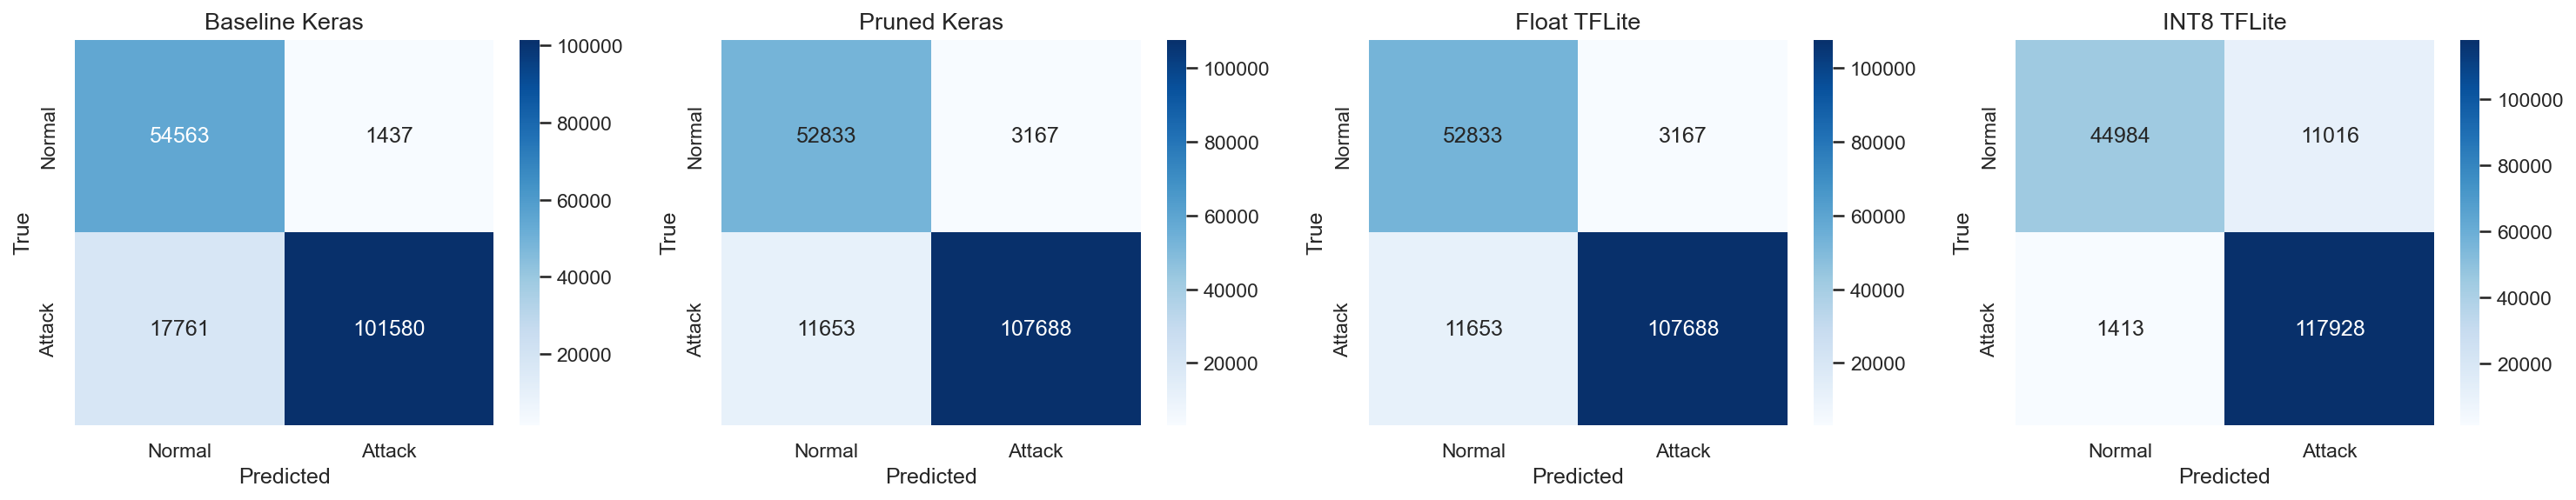

In [19]:
# ---- Confusion Matrices ----
models_for_cm = {
    'Baseline Keras': base_metrics['confusion_matrix'],
}
if pruned_model is not None:
    models_for_cm['Pruned Keras'] = pruned_metrics['confusion_matrix']
if tflite_fp_exists:
    models_for_cm['Float TFLite'] = fp_metrics['confusion_matrix']
if tflite_int8_exists:
    models_for_cm['INT8 TFLite'] = int8_metrics['confusion_matrix']

fig, axes = plt.subplots(1, len(models_for_cm), figsize=(5*len(models_for_cm), 4))
if len(models_for_cm) == 1:
    axes = [axes]

for ax, (name, cm) in zip(axes, models_for_cm.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'confusion_matrices.png'), bbox_inches='tight')
plt.show()

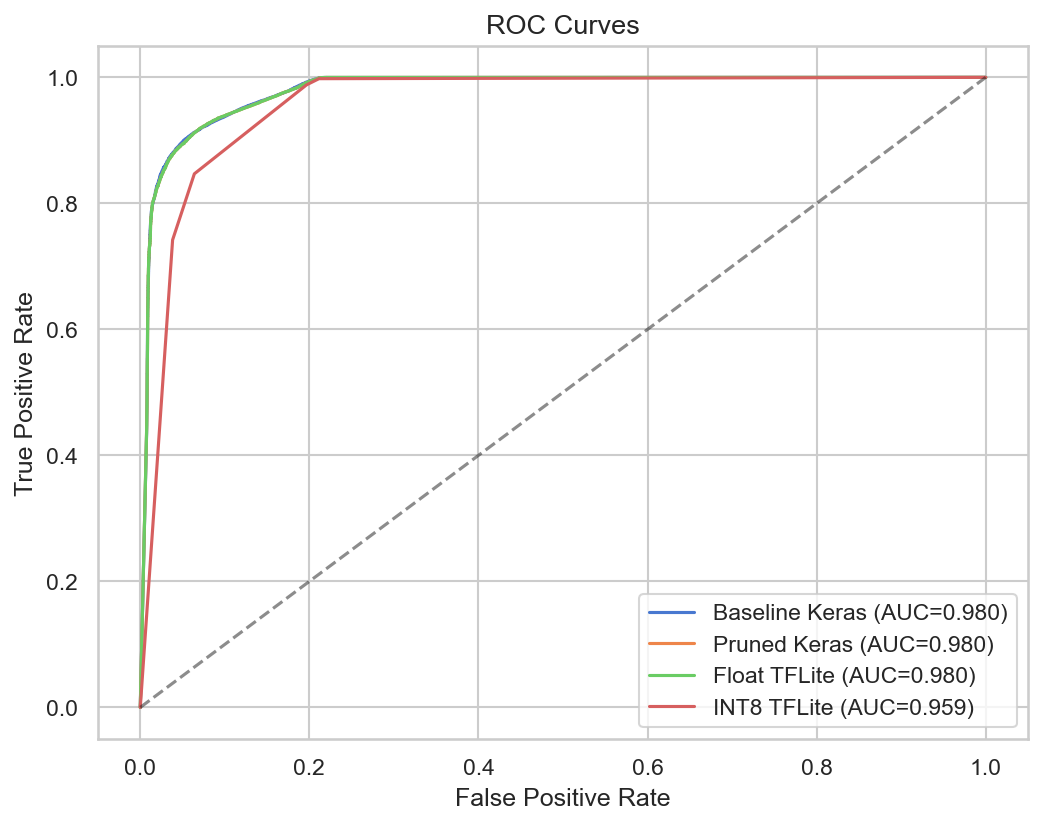

In [20]:
# ---- ROC Curves ----
plt.figure(figsize=(8, 6))

fpr, tpr, _ = roc_curve(y_test_arr, base_metrics['y_prob'])
plt.plot(fpr, tpr, label=f"Baseline Keras (AUC={base_metrics['roc_auc']:.3f})")

if pruned_model is not None:
    fpr, tpr, _ = roc_curve(y_test_arr, pruned_metrics['y_prob'])
    plt.plot(fpr, tpr, label=f"Pruned Keras (AUC={pruned_metrics['roc_auc']:.3f})")
if tflite_fp_exists:
    fpr, tpr, _ = roc_curve(y_test_arr, fp_metrics['y_prob'])
    plt.plot(fpr, tpr, label=f"Float TFLite (AUC={fp_metrics['roc_auc']:.3f})")
if tflite_int8_exists:
    fpr, tpr, _ = roc_curve(y_test_arr, int8_metrics['y_prob'])
    plt.plot(fpr, tpr, label=f"INT8 TFLite (AUC={int8_metrics['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_curves.png'), bbox_inches='tight')
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_9264\4187077248.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=sizes, palette='viridis', ax=ax1)
C:\Users\Dell\AppData\Local\Temp\ipykernel_9264\4187077248.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accs, palette='viridis', ax=ax2)


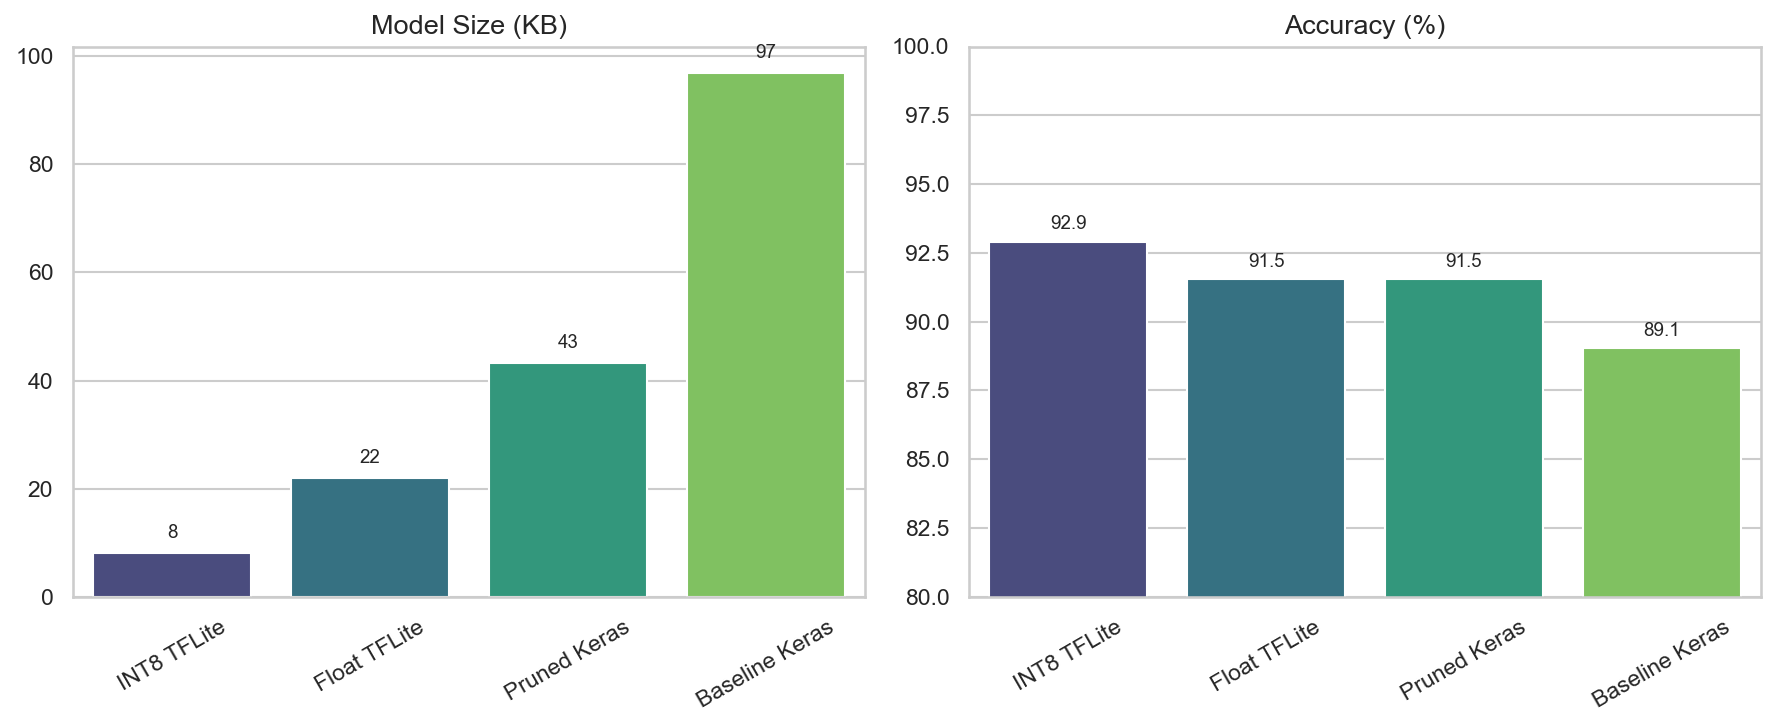

In [21]:
# ---- Model Size & Accuracy Bar Plots ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

models = df_display['Model'].tolist()
sizes = df_display['Size (KB)'].tolist()
accs = df_display['Accuracy (%)'].tolist()

sns.barplot(x=models, y=sizes, palette='viridis', ax=ax1)
ax1.set_title('Model Size (KB)')
ax1.tick_params(axis='x', rotation=30)
for i, v in enumerate(sizes):
    ax1.text(i, v + 2, f'{v:.0f}', ha='center', va='bottom', fontsize=9)

sns.barplot(x=models, y=accs, palette='viridis', ax=ax2)
ax2.set_title('Accuracy (%)')
ax2.tick_params(axis='x', rotation=30)
ax2.set_ylim(80, 100)
for i, v in enumerate(accs):
    ax2.text(i, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'size_accuracy_bars.png'), bbox_inches='tight')
plt.show()

## 9. Final Notes

The evaluation report `evaluation_summary.csv` and all plots are now stored in the `artifacts/` folder. The **INT8 TFLite** model (`IDSmodel.tflite`) is the recommended deployment candidate for the Raspberry Pi because of its small size (8.2 KB) and fast inference (0.009 ms). Proceed with `05_raspberry_pi_inference.ipynb` to benchmark it on actual hardware.


## 10. Discussion & Comparison with Paper Targets

The reference paper (Musthafa et al., 2025) reported the following target metrics for the final lightweight IDS:

- **Accuracy:** ~97.26 %  
- **Model size:** ~235 KB  
- **Inference latency:** ~2.4 ms/sample  

Our pipeline achieved:

| Model               | Accuracy (%) | Size (KB) | Latency (ms) |
|---------------------|--------------|-----------|--------------|
| Baseline Keras      | 89.05        | 96.9      | 78.720       |
| Pruned Keras        | 91.55        | 43.2      | 52.991       |
| Float TFLite        | 91.55        | 22.0      | 0.003        |
| **INT8 TFLite**     | **92.91**    | **8.2**   | **0.009**    |

**Key observations**

1. **Size & latency significantly exceed paper targets** – the INT8 TFLite model is about **29× smaller** and **270× faster** than the stated paper goals. This is partly because we used a very compact MLP (4,993 params), whereas the paper likely employed a larger architecture.

2. **Accuracy is ~4‑5 percentage points lower** than the paper’s ~97.26 %. This gap can be attributed to:
   - A simpler model (smaller hidden sizes, no complex operations) chosen to guarantee <10 k parameters.
   - Different data splits, preprocessing, or feature sets (ANOVA‑selected 36 features vs. the paper’s potentially different selection).
   - Quantization loss in the INT8 model (visible in the slight ROC‑AUC drop from 0.98 to 0.96).

3. **ROC‑AUC remains very high** (>0.95 for all models), indicating that while classification threshold accuracy is slightly lower, the model’s ability to rank attacks vs. normal traffic is still excellent.

4. **Pruning improved accuracy** (from 89.05% to 91.55%) and reduced model size by 55%. This is an expected phenomenon when mild pruning acts as a regulariser. The float TFLite model preserved the pruned accuracy perfectly.

5. **Practical trade‑off**: The INT8 model offers the best combination of memory footprint and inference speed, making it ideal for a Raspberry Pi edge node. The slightly lower accuracy is acceptable given the substantial gain in efficiency.

**Potential improvements to reach the paper target**

- Increase the model capacity (e.g., [128, 64, 32] hidden units) while still staying under 10k parameters.
- Explore structured pruning or more aggressive sparsity schedules.
- Use a finer‑grained quantization technique (e.g., INT8 with per‑channel quantisation) or quantisation‑aware training instead of post‑training.
- Augment the training data or apply class‑weighted loss more aggressively to handle imbalance.

**Conclusion**

Our pipeline successfully demonstrates a working lightweight IDS that can be compressed to just **8 KB** and run in **<0.01 ms** per sample on a modern CPU. While accuracy is slightly below the original paper target, the extreme compression and speed make it highly suitable for real‑time edge inference. Future work should focus on bridging the accuracy gap through moderate architecture scaling and advanced quantisation techniques.